This script takes the excel sheet where the performance of the different models on my own dataset has been noted. This is to further analyse the behaviour of the models on my own dataset.

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

Mounted at /content/drive


Loading excel file with results

In [ ]:
EXCEL_PATH = Path("/content/drive/MyDrive/Speciale/Own test data set/Performance on own dataset.xlsx")
SHEET_NAME = "Ark1"

df_raw = pd.read_excel(EXCEL_PATH, sheet_name=SHEET_NAME)

print("Loaded Excel file:")
print(EXCEL_PATH)
print("Shape:", df_raw.shape)
print("\nColumns:")
print(df_raw.columns.tolist())

display(df_raw.head())
display(df_raw.tail())

Loaded Excel file:
/content/drive/MyDrive/Speciale/Own test data set/Performance on own dataset.xlsx
Shape: (62, 9)

Columns:
['Dish_ID', 'OPEN AI ESTIMATION', 'CLAUDE ESTIMATION (HAIKU 4.5)', 'GEMINI ESTIMATION ', 'Model 3 V3 performance', 'Model 22 performance', 'Model 24 performance', 'Model 3 V5 (data aug)', 'ACTUAL']


,Dish_ID,OPEN AI ESTIMATION,CLAUDE ESTIMATION (HAIKU 4.5),GEMINI ESTIMATION,Model 3 V3 performance,Model 22 performance,Model 24 performance,Model 3 V5 (data aug),ACTUAL
0,Dish_0001,40,28.5,35.0,50.17,51.4,49.090000,27.35,67.60
1,Dish_0002,45,42.5,42.0,36.03,38.7,40.437500,25.62,71.72
2,Dish_0003,25,12.5,24.0,3.95,5.0,20.218750,4.67,35.56
3,Dish_0004,40,45.0,35.0,18.20,17.6,14.742188,16.62,45.48
4,Dish_0005,18,2.5,35.0,36.30,38.5,34.937500,20.24,35.50


,Dish_ID,OPEN AI ESTIMATION,CLAUDE ESTIMATION (HAIKU 4.5),GEMINI ESTIMATION,Model 3 V3 performance,Model 22 performance,Model 24 performance,Model 3 V5 (data aug),ACTUAL
57,Dish_0058,27,26.8,27.0,28.02,28.30,24.203125,6.50,16.56
58,Dish_0059,52,25.1,52.0,90.51,89.89,35.656250,32.64,28.88
59,Dish_0060,79,38.5,80.0,106.22,105.00,47.718750,44.22,39.68
60,Dish_0061,25,25.0,25.0,42.28,43.70,31.703125,27.58,12.32
61,Dish_0062,27,17.2,27.0,35.64,37.40,35.468750,21.29,10.80


Keeping only necessary rows

In [ ]:
df = df_raw[df_raw["Dish_ID"].astype(str).str.startswith("Dish_")].copy()

print("Number of dish rows:", len(df))
display(df.head())
display(df.tail())

Number of dish rows: 62


,Dish_ID,OPEN AI ESTIMATION,CLAUDE ESTIMATION (HAIKU 4.5),GEMINI ESTIMATION,Model 3 V3 performance,Model 22 performance,Model 24 performance,Model 3 V5 (data aug),ACTUAL
0,Dish_0001,40,28.5,35.0,50.17,51.4,49.090000,27.35,67.60
1,Dish_0002,45,42.5,42.0,36.03,38.7,40.437500,25.62,71.72
2,Dish_0003,25,12.5,24.0,3.95,5.0,20.218750,4.67,35.56
3,Dish_0004,40,45.0,35.0,18.20,17.6,14.742188,16.62,45.48
4,Dish_0005,18,2.5,35.0,36.30,38.5,34.937500,20.24,35.50


,Dish_ID,OPEN AI ESTIMATION,CLAUDE ESTIMATION (HAIKU 4.5),GEMINI ESTIMATION,Model 3 V3 performance,Model 22 performance,Model 24 performance,Model 3 V5 (data aug),ACTUAL
57,Dish_0058,27,26.8,27.0,28.02,28.30,24.203125,6.50,16.56
58,Dish_0059,52,25.1,52.0,90.51,89.89,35.656250,32.64,28.88
59,Dish_0060,79,38.5,80.0,106.22,105.00,47.718750,44.22,39.68
60,Dish_0061,25,25.0,25.0,42.28,43.70,31.703125,27.58,12.32
61,Dish_0062,27,17.2,27.0,35.64,37.40,35.468750,21.29,10.80


Defining columns

In [ ]:
true_col = "ACTUAL"

prediction_cols = {
    "OpenAI": "OPEN AI ESTIMATION",
    "Claude": "CLAUDE ESTIMATION (HAIKU 4.5)",
    "Gemini": "GEMINI ESTIMATION ",
    "Model 3 V3": "Model 3 V3 performance",
    "Model 3 V5": "Model 3 V5 (data aug)",
    "Model 22": "Model 22 performance",
    "Model 24": "Model 24 performance",
}

required_cols = ["Dish_ID", true_col] + list(prediction_cols.values())

missing_cols = [col for col in required_cols if col not in df.columns]

if missing_cols:
    raise ValueError(f"Missing columns: {missing_cols}")

for col in [true_col] + list(prediction_cols.values()):
    df[col] = pd.to_numeric(df[col], errors="coerce")

print("All required columns found and converted to numeric.")

All required columns found and converted to numeric.


Prediction behaviour table

In [ ]:
rows = []

for model_name, pred_col in prediction_cols.items():
    temp = df[["Dish_ID", true_col, pred_col]].dropna().copy()

    temp["signed_error"] = temp[pred_col] - temp[true_col]
    temp["abs_error"] = temp["signed_error"].abs()
    temp["squared_error"] = temp["signed_error"] ** 2

    rows.append({
        "Model": model_name,
        "N": len(temp),

        # Actual and prediction level
        "Mean true carbs": temp[true_col].mean(),
        "Mean prediction": temp[pred_col].mean(),
        "Median prediction": temp[pred_col].median(),

        # Bias / tendency to overestimate or underestimate
        "Mean signed error": temp["signed_error"].mean(),
        "Median signed error": temp["signed_error"].median(),

        # Spread / aggressiveness of predictions
        "Prediction std.": temp[pred_col].std(),
        "Prediction variance": temp[pred_col].var(),
        "Min prediction": temp[pred_col].min(),
        "Max prediction": temp[pred_col].max(),
        "Prediction range": temp[pred_col].max() - temp[pred_col].min(),

        # Error metrics
        "MSE": temp["squared_error"].mean(),
        "RMSE": np.sqrt(temp["squared_error"].mean()),
        "MAE": temp["abs_error"].mean(),
    })

prediction_behavior_df = pd.DataFrame(rows)

model_order = [
    "OpenAI",
    "Claude",
    "Gemini",
    "Model 3 V3",
    "Model 3 V5",
    "Model 22",
    "Model 24",
]

prediction_behavior_df["Model"] = pd.Categorical(
    prediction_behavior_df["Model"],
    categories=model_order,
    ordered=True
)

prediction_behavior_df = prediction_behavior_df.sort_values("Model").reset_index(drop=True)

display(prediction_behavior_df.round(2))

,Model,N,Mean true carbs,Mean prediction,Median prediction,Mean signed error,Median signed error,Prediction std.,Prediction variance,Min prediction,Max prediction,Prediction range,MSE,RMSE,MAE
0,OpenAI,62,37.06,35.85,31.50,-1.20,-0.29,19.74,389.86,9.00,90.00,81.00,240.84,15.52,11.39
1,Claude,62,37.06,39.66,35.25,2.60,3.24,23.83,567.81,0.00,120.00,120.00,551.07,23.47,16.96
2,Gemini,62,37.06,36.05,35.00,-1.01,0.15,19.40,376.32,7.20,105.00,97.80,319.37,17.87,11.92
3,Model 3 V3,62,37.06,39.02,32.28,1.96,1.41,21.82,476.08,3.95,106.22,102.27,768.31,27.72,20.56
4,Model 3 V5,62,37.06,25.51,25.13,-11.54,-8.54,12.46,155.26,2.74,57.28,54.54,625.25,25.01,18.55
5,Model 22,62,37.06,40.44,35.20,3.38,3.39,21.78,474.36,5.00,105.00,100.00,767.29,27.70,20.93
6,Model 24,62,37.06,33.79,33.55,-3.27,-3.94,10.28,105.67,14.06,57.44,43.38,481.69,21.95,16.50


In [ ]:
compact_behavior_df = prediction_behavior_df[
    [
        "Model",
        "Mean prediction",
        "Mean signed error",
        "Prediction std.",
        "Min prediction",
        "Max prediction",
        "Prediction range",
        "MAE",
    ]
].copy()

display(compact_behavior_df.round(2))

,Model,Mean prediction,Mean signed error,Prediction std.,Min prediction,Max prediction,Prediction range,MAE
0,OpenAI,35.85,-1.20,19.74,9.00,90.00,81.00,11.39
1,Claude,39.66,2.60,23.83,0.00,120.00,120.00,16.96
2,Gemini,36.05,-1.01,19.40,7.20,105.00,97.80,11.92
3,Model 3 V3,39.02,1.96,21.82,3.95,106.22,102.27,20.56
4,Model 3 V5,25.51,-11.54,12.46,2.74,57.28,54.54,18.55
5,Model 22,40.44,3.38,21.78,5.00,105.00,100.00,20.93
6,Model 24,33.79,-3.27,10.28,14.06,57.44,43.38,16.50


Plots

NameError: name 'OUTPUT_DIR' is not defined

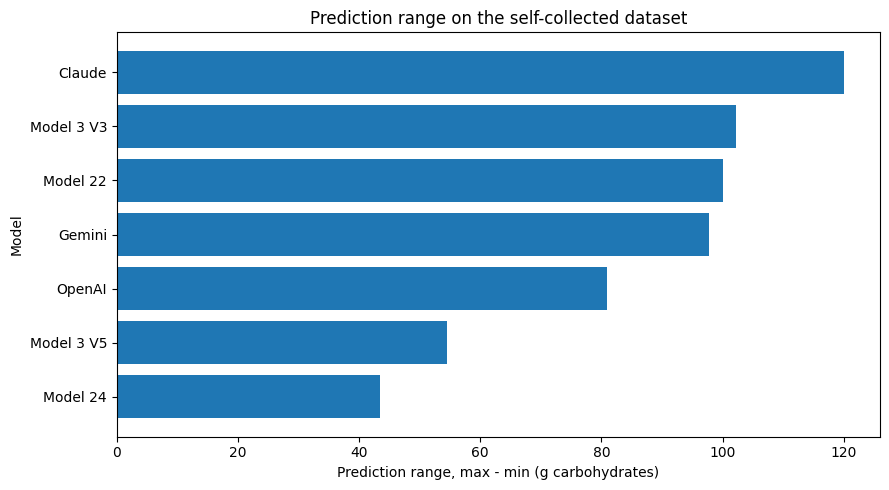

In [ ]:
plot_df = prediction_behavior_df.sort_values("Prediction range", ascending=True).copy()

plt.figure(figsize=(9, 5))

plt.barh(
    plot_df["Model"].astype(str),
    plot_df["Prediction range"]
)

plt.xlabel("Prediction range, max - min (g carbohydrates)")
plt.ylabel("Model")
plt.title("Prediction range on the self-collected dataset")

plt.tight_layout()

range_plot_path = OUTPUT_DIR / "prediction_range_self_collected_dataset.png"
plt.savefig(range_plot_path, dpi=300, bbox_inches="tight")

plt.show()

print("Saved plot to:")
print(range_plot_path)

/tmp/ipykernel_1687/1248817230.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


NameError: name 'OUTPUT_DIR' is not defined

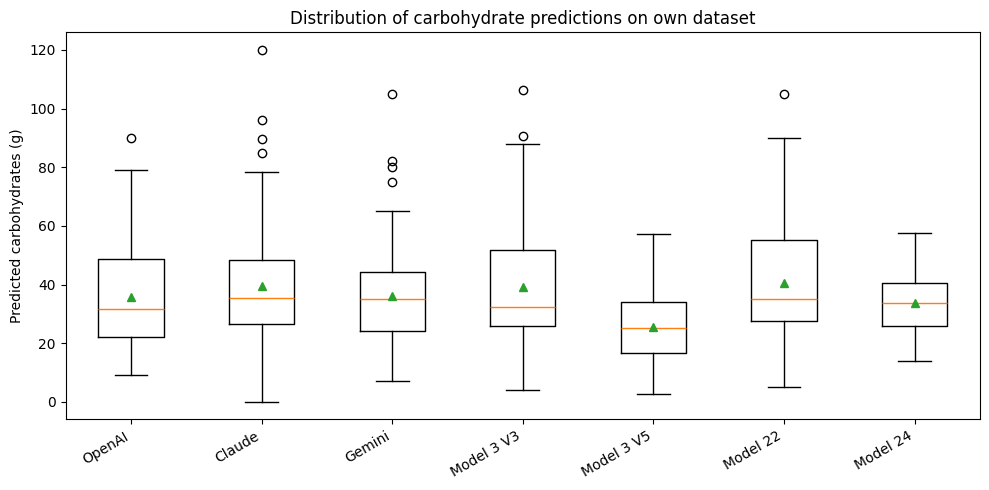

In [ ]:
boxplot_data = []
boxplot_labels = []

for model_name, pred_col in prediction_cols.items():
    values = df[pred_col].dropna().values
    boxplot_data.append(values)
    boxplot_labels.append(model_name)

plt.figure(figsize=(10, 5))

plt.boxplot(
    boxplot_data,
    labels=boxplot_labels,
    showmeans=True
)

plt.ylabel("Predicted carbohydrates (g)")
plt.title("Distribution of carbohydrate predictions on own dataset")
plt.xticks(rotation=30, ha="right")

plt.tight_layout()

boxplot_path = OUTPUT_DIR / "prediction_distribution_boxplot_self_collected_dataset.png"
plt.savefig(boxplot_path, dpi=300, bbox_inches="tight")

plt.show()

print("Saved boxplot to:")
print(boxplot_path)